In [1]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Load saved data splits
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

train_paths = data['train_paths']
val_paths = data['val_paths']
test_paths = data['test_paths']
train_labels = data['train_labels']
val_labels = data['val_labels']
test_labels = data['test_labels']
classes = data['classes']
class_to_idx = data['class_to_idx']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Data loaded successfully!")
print(f"Device: {device}")
print(f"Classes: {len(classes)}")
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Data loaded successfully!
Device: cpu
Classes: 15
Train: 14453 | Val: 3088 | Test: 3096


In [3]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = PlantDiseaseDataset(train_paths, train_labels, transform=train_transform)
val_dataset = PlantDiseaseDataset(val_paths, val_labels, transform=val_transform)
test_dataset = PlantDiseaseDataset(test_paths, test_labels, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Datasets and DataLoaders ready!")

Datasets and DataLoaders ready!


In [4]:
# Load the model architecture
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(2048, len(classes))

# Load the best weights from Day 4
model.load_state_dict(torch.load('models/resnet50_best.pth'))
model = model.to(device)

# Unfreeze ALL layers
for param in model.parameters():
    param.requires_grad = True

# Verify
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded from Day 4 checkpoint!")
print(f"\nTrainable parameters:")
print(f"  Total:     {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"\nAll layers unfrozen — full fine-tuning enabled!")

Model loaded from Day 4 checkpoint!

Trainable parameters:
  Total:     23,538,767
  Trainable: 23,538,767

All layers unfrozen — full fine-tuning enabled!


In [5]:
# Very low learning rate for fine-tuning
# We use different learning rates for different parts of the model
# Lower lr for early layers (they're already good)
# Slightly higher lr for the final layer (it needs more updating)
optimizer = torch.optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    {'params': model.layer2.parameters(), 'lr': 1e-5},
    {'params': model.layer3.parameters(), 'lr': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
], lr=1e-4)

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print("Optimizer configured with layer-wise learning rates:")
print("  layer1, layer2: lr = 0.00001  (early layers, mostly frozen in effect)")
print("  layer3, layer4: lr = 0.0001   (deeper features, moderate updates)")
print("  fc layer:       lr = 0.001    (classifier head, most updates)")

Optimizer configured with layer-wise learning rates:
  layer1, layer2: lr = 0.00001  (early layers, mostly frozen in effect)
  layer3, layer4: lr = 0.0001   (deeper features, moderate updates)
  fc layer:       lr = 0.001    (classifier head, most updates)


In [7]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

num_epochs = 5
best_val_acc = 91.9  # start from Day 4's best
train_losses, val_losses = [], []
train_accs, val_accs = [], []

checkpoint_path = 'models/finetune_checkpoint.pth'

# Resume if checkpoint exists
start_epoch = 0
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accs = checkpoint['train_accs']
    val_accs = checkpoint['val_accs']
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Starting fresh fine-tuning...")

print("Starting full fine-tuning...\n")

for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {running_loss/(batch_idx+1):.3f} "
                  f"| Acc: {100.*correct/total:.1f}%")

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/resnet50_finetuned.pth')
        print(f"  ✓ New best model saved! ({val_acc:.1f}%)")

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }, checkpoint_path)
    print(f"  ✓ Checkpoint saved!")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\n  Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.3f} | Val Acc:   {val_acc:.1f}%\n")

print(f"Fine-tuning complete! Best val accuracy: {best_val_acc:.1f}%")

Starting fresh fine-tuning...
Starting full fine-tuning...

Epoch 1/5
----------------------------------------
  Batch 10/452 | Loss: 0.448 | Acc: 85.3%
  Batch 20/452 | Loss: 0.431 | Acc: 86.7%
  Batch 30/452 | Loss: 0.413 | Acc: 87.1%
  Batch 40/452 | Loss: 0.392 | Acc: 87.8%
  Batch 50/452 | Loss: 0.389 | Acc: 87.7%
  Batch 60/452 | Loss: 0.373 | Acc: 88.3%
  Batch 70/452 | Loss: 0.361 | Acc: 88.7%
  Batch 80/452 | Loss: 0.351 | Acc: 88.9%
  Batch 90/452 | Loss: 0.343 | Acc: 89.3%
  Batch 100/452 | Loss: 0.331 | Acc: 89.6%
  Batch 110/452 | Loss: 0.321 | Acc: 89.9%
  Batch 120/452 | Loss: 0.307 | Acc: 90.3%
  Batch 130/452 | Loss: 0.304 | Acc: 90.4%
  Batch 140/452 | Loss: 0.301 | Acc: 90.4%
  Batch 150/452 | Loss: 0.303 | Acc: 90.4%
  Batch 160/452 | Loss: 0.303 | Acc: 90.5%
  Batch 170/452 | Loss: 0.303 | Acc: 90.7%
  Batch 180/452 | Loss: 0.293 | Acc: 91.0%
  Batch 190/452 | Loss: 0.291 | Acc: 91.1%
  Batch 200/452 | Loss: 0.287 | Acc: 91.2%
  Batch 210/452 | Loss: 0.281 | Acc: 9

In [9]:
# Load the best model (epoch 4, 99.6% val acc)
model.load_state_dict(torch.load('models/resnet50_finetuned.pth'))

# Run on test set - this is data the model has NEVER seen
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")
print(f"\nVal Accuracy:  99.6%")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"\nDifference: {abs(99.6 - test_acc):.2f}% — model generalises well if this is small")

Final Test Accuracy: 99.52%
Final Test Loss:     0.0229

Val Accuracy:  99.6%
Test Accuracy: 99.52%

Difference: 0.08% — model generalises well if this is small


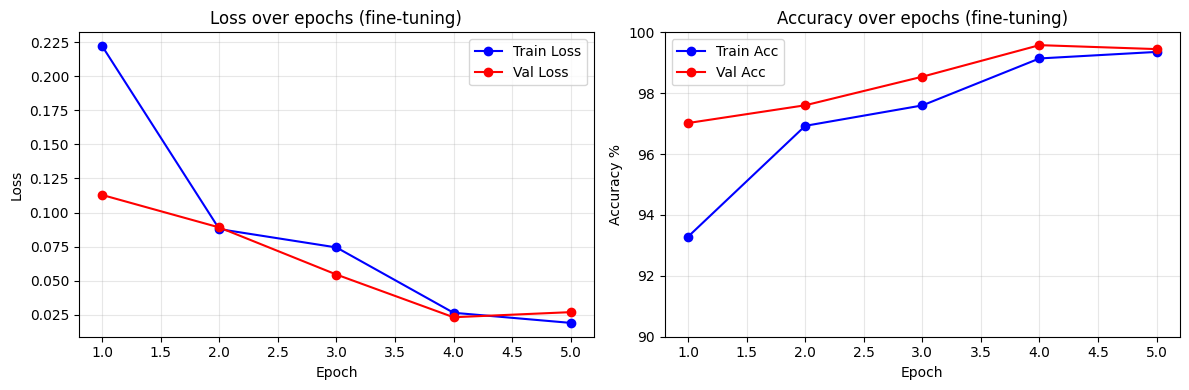

Saved to outputs/finetune_curves.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, 6)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_title('Loss over epochs (fine-tuning)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-o', label='Train Acc')
ax2.plot(epochs, val_accs, 'r-o', label='Val Acc')
ax2.set_title('Accuracy over epochs (fine-tuning)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.set_ylim([90, 100])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/finetune_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/finetune_curves.png")